In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from torch import nn
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix
import os
import tqdm
import random
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import pandas as pd
import os
import glob
import pyedflib
import h5py
import numpy as np
import pandas as pd
import datetime
from scipy.signal import resample
import matplotlib.pyplot as plt
from tqdm import tqdm
import multiprocessing
from loguru import logger
import argparse
import warnings
from scipy.signal import butter, filtfilt
import mne
sys.path.append("..")
sys.path.append("../sleepfm")
"""from preprocessing.preprocessing import EDFToHDF5Converter"""
from models.dataset import SetTransformerDataset, collate_fn
from models.models import SetTransformer, SleepEventLSTMClassifier, DiagnosisFinetuneFullLSTMCOXPHWithDemo
import h5py
from utils import load_config, load_data, save_data, count_parameters
from torch.utils.data import Dataset, DataLoader

In [57]:
base_save_path = "test_data"
os.makedirs(base_save_path, exist_ok=True)
print(base_save_path)

test_data


In [58]:
class EDFToHDF5Converter:
    def __init__(self, root_dir, target_dir, resample_rate=512, num_threads=1, num_files=-1, channels=None):
        self.resample_rate = resample_rate 
        self.root_dir = root_dir
        self.target_dir = target_dir
        self.num_threads = num_threads
        self.num_files = num_files
        self.channels = channels
        self.file_locations = self.get_files() 
        # self.scorers = ['ES','LS','MS']
        self.flow_events = {'Central Apnea': 1, 'Mixed Apnea': 2, 'Obstructive Apnea': 3, 'Hypopnea': 4, 'RERA': 5}
        self.plm_events = {'P-Marker': 1, 'I-Marker': 2, 'LM Body position': 3, 'LM Resp': 4}
        self.arousal_events = {'Autonomic arousals': 1, 'Respiratory Arousal': 2}
        self.sleep_stages = {'Wake': 0, 'Rem': 1, 'N1': 2, 'N2': 3, 'N3': 4, 'Artifact': 5}


    def get_files(self):
        # Search for all '.edf' files within each subdirectory of the root directory
        file_paths = glob.glob(os.path.join(self.root_dir, '**/*.[eE][dD][fF]'), recursive=True)
        file_names = [os.path.basename(path) for path in file_paths]
        return file_paths, file_names
    
    def extract_start_time(self, file_path):
        with open(file_path, 'r') as file:
            lines = [next(file) for _ in range(5)]
            
        for line in lines:
            if line.startswith("Start Time:"):
                return line.split(": ", 1)[1].strip()
        return "Start Time not found"

    def create_signal_from_events(self, df, total_seconds, event_type = None):
        valid_types = {'flow', 'plm', 'arousal','stages'}
        if event_type not in valid_types:
            raise ValueError("event_type must be 'flow', 'plm', or 'arousal'")
        
        total_samples = int(total_seconds * self.resample_rate)
        # make initial array of zeros with length total_sec
        event_array = np.zeros(total_samples)

        # go through each event and mark the corresponding seconds in the array
        for _, row in df.iterrows():
            event_start = int(row['sec_from_start'] * self.resample_rate)
            event_stop = int(row['sec_from_start'] * self.resample_rate + row['dur'] * self.resample_rate)
            if event_type == 'flow':
                event_code = self.flow_events.get(row['event_type'], 0)
            elif event_type == 'plm':
                event_code = self.plm_events.get(row['event_type'], 0)
            elif event_type == 'arousal':
                event_code = self.arousal_events.get(row['event_type'], 0)
            elif event_type == 'stages':
                event_code = self.sleep_stages.get(row['event_type'])
            
            event_array[event_start:event_stop] = event_code
        
        return event_array

    def make_event_dataframe(self, folder, event_type = None):
        valid_types = {'flow', 'plm', 'arousal','stages'}
        if event_type not in valid_types:
            raise ValueError("event_type must be 'flow', 'plm', or 'arousal'")
        if event_type == 'flow':
            flow_file = os.path.join(self.root_dir,folder,'Flow Events.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        elif event_type == 'plm':
            flow_file = os.path.join(self.root_dir,folder,'PLM Events.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        elif event_type == 'arousal':
            flow_file = os.path.join(self.root_dir,folder,'Autonomic arousals.txt')
            dfAutonomic = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
            flow_file = os.path.join(self.root_dir,folder,'Classification arousals.txt')
            dfClassification = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
            df = pd.concat([dfAutonomic,dfClassification], ignore_index=True)
        elif event_type == 'stages':
            flow_file1 = os.path.join(self.root_dir,folder,'Flow Events.txt')
            start_time = self.extract_start_time(file_path = flow_file1)
            start_time = datetime.datetime.strptime(start_time, "%m/%d/%Y %I:%M:%S %p")
            flow_file = os.path.join(self.root_dir,folder,'Sleep profile.txt')
            df = pd.read_csv(flow_file, delimiter=';',skiprows=7, names=['start', 'event_type']) 
            df['start'] = pd.to_datetime(df['start'], format='%H:%M:%S,%f').dt.time
            df['sec_from_start'] = df['start'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())
            df['dur'] = 30
            df['event_type'] = df['event_type'].str.strip()
            if df['sec_from_start'].iloc[0] < 0:
                df['dur'][0] = 30 + df['sec_from_start'].iloc[0]
                df['sec_from_start'].iloc[0] = 0
            df.loc[df.sec_from_start < 0, 'sec_from_start'] += 24*60*60
            return df

        # df = pd.read_csv(flow_file, delimiter=';',skiprows=5, names=['start-stop', 'duration', 'event_type'])
        if len(df.values) != 0:
            df[['start', 'stop']] = df['start-stop'].str.split('-', expand=True)

            start_time = self.extract_start_time(file_path = flow_file)
            start_time = datetime.datetime.strptime(start_time, "%m/%d/%Y %I:%M:%S %p")

            df['start'] = pd.to_datetime(df['start'], format='%H:%M:%S,%f').dt.time
            df['stop'] = pd.to_datetime(df['stop'], format='%H:%M:%S,%f').dt.time
            df['sec_from_start'] = df['start'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())
            df['sec_from_stop'] = df['stop'].apply(lambda x: (datetime.datetime.combine(datetime.date(1,1,1),x) - datetime.datetime.combine(datetime.date(1,1,1),start_time.time())).total_seconds())

            df['duration'] = pd.to_numeric(df['duration'])

            df = df[['start', 'stop', 'duration', 'event_type', 'sec_from_start','sec_from_stop']]

            df.loc[df.sec_from_start < 0, 'sec_from_start'] += 24*60*60
            df.loc[df.sec_from_stop < 0, 'sec_from_stop'] += 24*60*60
            df['dur'] = df['sec_from_stop'] - df['sec_from_start']
        else:
            df  = pd.DataFrame(columns = ['start', 'stop', 'duration', 'event_type', 'sec_from_start','sec_from_stop', 'dur'])

        return df

    def convert_events(self, folder,total_seconds,event_type):
        df_events = self.make_event_dataframe(folder, event_type=event_type)
        event_array = self.create_signal_from_events(df=df_events, total_seconds=total_seconds, event_type=event_type)
        return event_array

    def read_edf_old(self, file_path):
        logger.info('reading edf')
        with pyedflib.EdfReader(file_path) as edf:
            signals = [edf.readSignal(i) for i in range(edf.signals_in_file)]
            sample_rates = np.array([edf.getSampleFrequency(i) for i in range(edf.signals_in_file)])
            channel_names = np.array([edf.getLabel(i) for i in range(edf.signals_in_file)])
            # annotations = []#edf.readAnnotations()
        return signals, sample_rates, channel_names
    
    def read_edf(self, file_path):
        logger.info(f'Reading EDF: {os.path.basename(file_path)}')
        
        try:
            # Charger avec filtrage de canaux si spécifié
            if self.channels is not None and len(self.channels) > 0:
                # Vérifier d'abord quels canaux existent
                logger.info(f'Checking available channels...')
                raw_temp = mne.io.read_raw_edf(file_path,include=self.channels, preload=False, verbose=False)
                
                available_channels = [ch for ch in self.channels if ch in raw_temp.ch_names]
                missing_channels = set(self.channels) - set(available_channels)
                
                if missing_channels:
                    logger.warning(f"⚠️  Canaux manquants: {missing_channels}")
                
                if not available_channels:
                    raise ValueError(f"❌ Aucun des canaux spécifiés n'a été trouvé dans {file_path}\n"
                                f"   Canaux demandés: {self.channels}\n"
                                f"   Canaux disponibles: {raw_temp.ch_names}")
                
                logger.info(f'✅ Chargement de {len(available_channels)}/{len(self.channels)} canaux')
                raw = mne.io.read_raw_edf(file_path, include=available_channels, preload=True, verbose=False)
            else:
                # Charger tous les canaux si aucun filtre spécifié
                logger.info('Loading all channels (no filter specified)')
                raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
            
            # Extraire les données
            signals = [raw.get_data(picks=[ch_name])[0] for ch_name in raw.ch_names]
            sample_rates = np.array([raw.info['sfreq'] for _ in raw.ch_names])
            channel_names = np.array(raw.ch_names)
            
            logger.info(f'✅ Loaded {len(channel_names)} channels, {len(signals[0])} samples at {sample_rates[0]} Hz')
            
            return signals, sample_rates, channel_names
            
        except Exception as e:
            logger.error(f"❌ Error reading {file_path}: {str(e)}")
            raise

    def resample_signals_old(self, signals, sample_rates):
        # Vectorization and broadcasting could be applied within the resample function itself
        logger.info('resampling signals')
        resampled_signals = [resample(signal, int(len(signal) * self.resample_rate / rate))
                             for signal, rate in zip(signals, sample_rates)]
        standardized_signals = [(signal - np.mean(signal)) / np.std(signal) for signal in resampled_signals]
        # add signal names as input and filter the spo2 preprocessing as scaled 0 to 1
        return np.stack(standardized_signals)# Using np.stack for proper array dimensions


    def safe_standardize(self, signal):
        mean = np.mean(signal)
        std = np.std(signal)
        
        if std == 0:
            standardized_signal = (signal - mean)
        else:
            standardized_signal = (signal - mean) / std
        
        return standardized_signal
        
    def filter_signal(self, signal, sample_rate):
        print("Filtering signal")
        nyquist_freq = sample_rate / 2
        cutoff = min(self.resample_rate / 2, nyquist_freq)
        normalized_cutoff = cutoff / nyquist_freq
        b, a = butter(4, normalized_cutoff, btype='low', analog=False)
        filtered_signal = filtfilt(b, a, signal)
        return filtered_signal

    def resample_signals(self, signals, sample_rates):
        logger.info('resampling signals')
        resampled_signals = []
        for signal, rate in zip(signals, sample_rates):
            # Calculate the duration of the signal
            duration = len(signal) / rate
            
            # Original time points
            original_time_points = np.linspace(0, duration, num=len(signal), endpoint=False)
            
            # New sample rate and new time points
            new_sample_count = int(duration * self.resample_rate)
            new_time_points = np.linspace(0, duration, num=new_sample_count, endpoint=False)

            #filter signal
            if rate > self.resample_rate:
                signal = self.filter_signal(signal, rate)
            
            # Linear interpolation
            resampled_signal = np.interp(new_time_points, original_time_points, signal)
            
            # Standardize the resampled signal (optional, based on your need)
            # standardized_signal = (resampled_signal - np.mean(resampled_signal)) / np.std(resampled_signal)
            standardized_signal = self.safe_standardize(resampled_signal)
            
            if np.isnan(standardized_signal).any():
                logger.info('Found NaN in the resampled signal.')
                # Handle the NaN case here (e.g., skip or fix the signal)
                continue

            resampled_signals.append(standardized_signal)

        
        return np.stack(resampled_signals)  # Stack for a consistent output format

    def save_to_hdf5(self, signals, channel_names, annotation_signals, annotation_names, file_path):
        logger.info('saving hdf5')
        samples_per_chunk = 5 * 60 * self.resample_rate
        with h5py.File(file_path, 'w') as hdf:
            for signal, name in zip(signals, channel_names):
                dataset_name = self._get_unique_name(hdf, name)
                hdf.create_dataset(dataset_name, data=signal,
                                   dtype='float16', chunks=(samples_per_chunk,), compression="gzip")

            for annot_signal, annot_name in zip(annotation_signals, annotation_names):
                hdf.create_dataset(annot_name, data=annot_signal)

    def _get_unique_name(self, hdf, base_name):
        # Helper method to ensure dataset names are unique
        i = 1
        unique_name = base_name
        while unique_name in hdf:
            unique_name = f"{base_name}_{i}"
            i += 1
        return unique_name

    def get_annotations(self, total_seconds, folder):
        # folder_path = 'C:/Users/45223/OneDrive - Danmarks Tekniske Universitet/PhD/Oliver_triple_scored/triple_scored_studies1/CSA009/ES'
        flow_events = self.convert_events(folder = folder, total_seconds = total_seconds, event_type = 'flow')
        plm_events = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'plm')
        arousal_events = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'arousal')
        sleep_stages = self.convert_events( folder = folder, total_seconds = total_seconds, event_type = 'stages')

        return flow_events, plm_events, arousal_events, sleep_stages
    
    def convert(self, edf_path, hdf5_path):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        total_duration_seconds = len(signals[0])/sample_rates[0]
        event_signals = []
        event_signal_names = []
        self.save_to_hdf5(resampled_signals, channel_names,event_signals,event_signal_names, hdf5_path)

    def convert_multiprocessing(self, args):
        edf_files = args

        for edf_file in tqdm(edf_files, desc="Converting EDF files"):

            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir, edf_file.split('/')[-1].replace(replace_str, '.hdf5'))

            if os.path.exists(hdf5_file):
                logger.info(f"File already processed: {hdf5_file}")
                continue
            try:
                self.convert(edf_file, hdf5_file)
            except Exception as e:
                warnings.warn(f"Warning: Could not process the file {edf_file}. Error: {str(e)}")
                continue
        return [1]

    def convert_all(self):
        edf_files, edf_names = self.get_files() 
        # folders = self.get_folders()
        for edf_file in tqdm(edf_files, desc="Converting EDF files"):
            # edf_files = [os.path.join(folder, f) for f in os.listdir(os.path.join(self.root_dir,folder)) if f.endswith('.edf')]
            # edf_file = os.path.join(self.root_dir,edf_files[0])
            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir,edf_file.split('/')[-1].replace(replace_str, '.hdf5'))
            # logger.info(edf_file)
            # logger.info(hdf5_file)

            try:
                self.convert(edf_file, hdf5_file)
            except Exception as e:
                warnings.warn(f"Warning: Could not process the file {edf_file}. Error: {str(e)}")
                continue

    def convert_all_multiprocessing(self):
        edf_files, edf_names = self.get_files() 

        if self.num_files != -1:
            edf_files = edf_files[:self.num_files]

        edf_files_chunks = np.array_split(edf_files, self.num_threads)
        tasks = [(edf_files_chunk) for edf_files_chunk in edf_files_chunks]
        with multiprocessing.Pool(self.num_threads) as pool:
            preprocessed_results = [y for x in pool.imap_unordered(self.convert_multiprocessing, tasks) for y in x]

    def convert_with_annot(self, edf_path, hdf5_path, folder):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        total_duration_seconds = len(signals[0])/sample_rates[0]
        event_signals = []
        event_signal_names = []
        for scorer in self.scorers:
            scorer_folder = os.path.join(folder, scorer) 
            flow_events, plm_events, arousal_events, sleep_stages = self.get_annotations(total_seconds = total_duration_seconds, folder = scorer_folder)
            event_signals.extend([flow_events, plm_events, arousal_events, sleep_stages])
            event_signal_names.extend(['flow_events'+scorer, 'plm_events'+scorer, 'arousal_events'+scorer, 'sleep_stages'+scorer])
        self.save_to_hdf5(resampled_signals, channel_names,event_signals,event_signal_names, hdf5_path)

    def convert_all_with_annot(self):
        edf_files, edf_names = self.get_files() 
        folders = self.get_folders()
        for folder in tqdm(folders, desc="Converting EDF files"):
            edf_files = [os.path.join(folder, f) for f in os.listdir(os.path.join(self.root_dir,folder)) if f.lower().endswith('.edf')]
            edf_file = os.path.join(self.root_dir,edf_files[0])
            # header = self.extract_end_time(edf_file)
            # hdf5_file = os.path.join(self.root_dir, edf_file.replace('.edf', '.hdf5'))
            if edf_file.endswith(".edf"):
                replace_str = ".edf"
            elif edf_file.endswith(".EDF"):
                replace_str = ".EDF"
            hdf5_file = os.path.join(self.target_dir,edf_file.split('\\')[-1].replace(replace_str, '.hdf5'))

            # logger.info(hdf5_file)
            self.convert_with_annot(edf_file, hdf5_file, folder)
    def plot_results(self, resampled_signals, channel_names):
        print("plotting resampled_signals")
        num_signals = len(resampled_signals)
        fig, axs = plt.subplots(num_signals, 1, figsize=(15, 3*num_signals), sharex=True)
        samples_to_plot = 10 * self.resample_rate
        sample_to_start = 10 * self.resample_rate
        for i, (signal, name) in enumerate(zip(resampled_signals, channel_names)):
            signal_chunk = signal[sample_to_start:sample_to_start+samples_to_plot]
            axs[i].plot(signal_chunk)
            axs[i].set_title(name)
            axs[i].set_ylabel('Amplitude')
        
        axs[-1].set_xlabel('Samples')
        plt.tight_layout()
        plt.show()

    def plot_first_results(self, resampled_signals, channel_names):
        print("plotting resampled_signals")
        num_signals = len(resampled_signals)
        fig = plt.figure(figsize=(15, 3))
        samples_to_plot = 10 * self.resample_rate
        sample_to_start = 10 * self.resample_rate
        for i, (signal, name) in enumerate(zip(resampled_signals, channel_names)):
            signal_chunk = signal[sample_to_start:sample_to_start+samples_to_plot]
            plt.plot(signal_chunk)
            plt.title(name)
            plt.ylabel('Amplitude')
            break
        
        plt.xlabel('Samples')
        plt.tight_layout()
        plt.show()

    def process_and_plot_single_file(self, edf_path):
        signals, sample_rates, channel_names = self.read_edf(edf_path)
        resampled_signals = self.resample_signals(signals, sample_rates)
        #self.plot_results(resampled_signals, channel_names)
        self.plot_first_results(resampled_signals, channel_names)
    


In [59]:
root_dir = "/edf_root"      # dummy root not used for a single file conversion
target_dir = "/note"    # dummy target not used for a single file conversion

edf_path = "C:\\Users\\gabri\\Desktop\\stage_sommeil\\algo\\data_test\\C1_012_PSG1.edf"
hdf5_path = os.path.join(base_save_path, "test_psg.hdf5")

CHANNEL_GROUPS = {
    "EEG": ["Fp1", "C3", "O1", "C4"],       
    "EOG": ["EOG G", "EOG D"],
    "EMG": ["EMG 1", "EMG 2"],          
    "EKG": ["ECG"],
    "REF": ["A2"],   
    "RESP": ["Thermistance", "Flow",]                   
}
CHANNEL_OI = sorted({ch for grp in CHANNEL_GROUPS.values() for ch in grp})

converter = EDFToHDF5Converter(
    root_dir=root_dir,
    target_dir=target_dir,
    resample_rate=128
    ,channels=CHANNEL_OI
)

# run for single file conversion
converter.convert(edf_path, hdf5_path)

2026-02-10 21:48:40.693 | INFO     | __main__:read_edf:129 - Reading EDF: C1_012_PSG1.edf
2026-02-10 21:48:40.695 | INFO     | __main__:read_edf:135 - Checking available channels...
2026-02-10 21:48:41.516 | WARNING  | __main__:read_edf:142 - ⚠️  Canaux manquants: {'Fp1'}
2026-02-10 21:48:41.517 | INFO     | __main__:read_edf:149 - ✅ Chargement de 11/12 canaux
2026-02-10 21:48:46.696 | INFO     | __main__:read_edf:161 - ✅ Loaded 11 channels, 8417024 samples at 256.0 Hz
2026-02-10 21:48:46.758 | INFO     | __main__:resample_signals:200 - resampling signals


Filtering signal
Filtering signal
Filtering signal
Filtering signal
Filtering signal
Filtering signal
Filtering signal
Filtering signal
Filtering signal
Filtering signal
Filtering signal


2026-02-10 21:48:53.171 | INFO     | __main__:save_to_hdf5:235 - saving hdf5


In [60]:
model_path = "../sleepfm/checkpoints/model_base"
channel_groups_path = "../sleepfm/configs/channel_groups.json"
config_path = os.path.join(model_path, "config.json")

config = load_config(config_path)
modality_types = config["modality_types"]
in_channels = config["in_channels"]
patch_size = config["patch_size"]
embed_dim = config["embed_dim"]
num_heads = config["num_heads"]
num_layers = config["num_layers"]
pooling_head = config["pooling_head"]
dropout = 0.0

In [61]:
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Version PyTorch: {torch.__version__}")
model_class = getattr(sys.modules[__name__], config['model'])
model = model_class(in_channels, patch_size, embed_dim, num_heads, num_layers, pooling_head=pooling_head, dropout=dropout)

device = torch.device("cuda")
print(device)
if device.type == "cuda":
    model = torch.nn.DataParallel(model)

model.to(device)
total_layers, total_params = count_parameters(model)
print(f'Trainable parameters: {total_params / 1e6:.2f} million')
print(f'Number of layers: {total_layers}')

CUDA disponible: True
Version PyTorch: 2.5.1+cu121
cuda
Trainable parameters: 4.44 million
Number of layers: 93


In [62]:
checkpoint = torch.load(os.path.join(model_path, "best.pt"))
model.load_state_dict(checkpoint["state_dict"])
model.eval()

C:\Users\gabri\AppData\Local\Temp\ipykernel_69044\2740997419.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join(model_path, "best.pt"))

DataParallel(
  (module): SetTransformer(
    (patch_embedding): Tokenizer(
      (tokenizer): Sequential(
        (0): Conv1d(1, 4, kernel_size=(5,), stride=(2,), padding=(2,))
        (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ELU(alpha=1.0)
        (3): LayerNorm((4, 320), eps=1e-05, elementwise_affine=True)
        (4): Conv1d(4, 8, kernel_size=(5,), stride=(2,), padding=(2,))
        (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ELU(alpha=1.0)
        (7): LayerNorm((8, 160), eps=1e-05, elementwise_affine=True)
        (8): Conv1d(8, 16, kernel_size=(5,), stride=(2,), padding=(2,))
        (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (10): ELU(alpha=1.0)
        (11): LayerNorm((16, 80), eps=1e-05, elementwise_affine=True)
        (12): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
        (13): BatchNorm1d(32, eps=1

In [63]:
CATEGORY_MAPPING = {
    "EEG": "BAS",
    "EOG": "BAS",
    "REF": "BAS",
    "ECG": "EKG",
    "EMG": "EMG",
    "RESP": "RESP",
    "EKG": "EKG"
}
CHANNEL_GROUPS_FOR_MODEL = {'BAS': [], 'EKG': [], 'RESP': [], 'EMG': []}

for category, channels in CHANNEL_GROUPS.items():
    model_category = CATEGORY_MAPPING.get(category, 'BAS')
    CHANNEL_GROUPS_FOR_MODEL[model_category].extend(channels)
print(CHANNEL_GROUPS_FOR_MODEL)

{'BAS': ['Fp1', 'C3', 'O1', 'C4', 'EOG G', 'EOG D', 'A2'], 'EKG': ['ECG'], 'RESP': ['Thermistance', 'Flow'], 'EMG': ['EMG 1', 'EMG 2']}


In [64]:
hdf5_paths = [os.path.join(base_save_path, "test_psg.hdf5")]
dataset = SetTransformerDataset(config, CHANNEL_GROUPS_FOR_MODEL , hdf5_paths=hdf5_paths, split="test")

dataloader = torch.utils.data.DataLoader(dataset, 
                                            batch_size=16, 
                                            num_workers=1, 
                                            shuffle=False, 
                                            collate_fn=collate_fn)

Indexing files: 100%|██████████| 1/1 [00:09<00:00,  9.65s/it]


In [65]:
output = os.path.join(base_save_path, "test_emb")
output_5min_agg = os.path.join(base_save_path, "test_5min_agg_emb")
os.makedirs(output, exist_ok=True)
os.makedirs(output_5min_agg, exist_ok=True)

In [66]:
with torch.no_grad():
    with tqdm(total=len(dataloader)) as pbar:
        for batch in dataloader:
            batch_data, mask_list, file_paths, dset_names_list, chunk_starts = batch
            (bas, resp, ekg, emg) = batch_data
            (mask_bas, mask_resp, mask_ekg, mask_emg) = mask_list

            bas = bas.to(device, dtype=torch.float)
            resp = resp.to(device, dtype=torch.float)
            ekg = ekg.to(device, dtype=torch.float)
            emg = emg.to(device, dtype=torch.float)

            mask_bas = mask_bas.to(device, dtype=torch.bool)
            mask_resp = mask_resp.to(device, dtype=torch.bool)
            mask_ekg = mask_ekg.to(device, dtype=torch.bool)
            mask_emg = mask_emg.to(device, dtype=torch.bool)

            embeddings = [
                model(bas, mask_bas),
                model(resp, mask_resp),
                model(ekg, mask_ekg),
                model(emg, mask_emg),
            ]
            # Model gives two kinds of embeddings. Granular 5 second-level embeddings and aggregated 5 minute-level embeddings. We save both of them below. 

            embeddings_new = [e[0].unsqueeze(1) for e in embeddings]

            for i in range(len(file_paths)):
                file_path = file_paths[i]
                chunk_start = chunk_starts[i]
                subject_id = os.path.basename(file_path).split('.')[0]
                output_path = os.path.join(output_5min_agg, f"{subject_id}.hdf5")

                with h5py.File(output_path, 'a') as hdf5_file:
                    for modality_idx, modality_type in enumerate(config["modality_types"]):
                        if modality_type in hdf5_file:
                            dset = hdf5_file[modality_type]
                            chunk_start_correct = chunk_start // (embed_dim * 5 * 60)
                            chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                            if dset.shape[0] < chunk_end:
                                dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                            dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                        else:
                            hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])

            embeddings_new = [e[1] for e in embeddings]

            for i in range(len(file_paths)):
                file_path = file_paths[i]
                chunk_start = chunk_starts[i]
                subject_id = os.path.basename(file_path).split('.')[0]
                output_path = os.path.join(output, f"{subject_id}.hdf5")

                with h5py.File(output_path, 'a') as hdf5_file:
                    for modality_idx, modality_type in enumerate(config["modality_types"]):
                        if modality_type in hdf5_file:
                            dset = hdf5_file[modality_type]
                            chunk_start_correct = chunk_start // (embed_dim * 5)
                            chunk_end = chunk_start_correct + embeddings_new[modality_idx][i].shape[0]
                            if dset.shape[0] < chunk_end:
                                dset.resize((chunk_end,) + embeddings_new[modality_idx][i].shape[1:])
                            dset[chunk_start_correct:chunk_end] = embeddings_new[modality_idx][i].cpu().numpy()
                        else:
                            hdf5_file.create_dataset(modality_type, data=embeddings_new[modality_idx][i].cpu().numpy(), chunks=(embed_dim,) + embeddings_new[modality_idx][i].shape[1:], maxshape=(None,) + embeddings_new[modality_idx][i].shape[1:])
            pbar.update()

100%|██████████| 7/7 [00:16<00:00,  2.32s/it]


In [67]:
print(embeddings[0][1].shape)
print(embeddings[0][0].shape)

torch.Size([13, 60, 128])
torch.Size([13, 128])


In [68]:
sleep_staging_model_path = "../sleepfm/checkpoints/model_sleep_staging"
sleep_staging_config = load_data(os.path.join(sleep_staging_model_path, "config.json"))

sleep_staging_model_params = sleep_staging_config['model_params']
sleep_staging_model_class = getattr(sys.modules[__name__], sleep_staging_config['model'])
print(sleep_staging_model_params)
print(sleep_staging_model_class)

sleep_staging_model = sleep_staging_model_class(**sleep_staging_model_params).to(device)
sleep_staging_model_name = type(sleep_staging_model).__name__
sleep_staging_model = nn.DataParallel(sleep_staging_model)

{'embed_dim': 128, 'num_heads': 4, 'num_layers': 1, 'num_classes': 5, 'pooling_head': 4, 'dropout': 0.3, 'max_seq_length': 8196}
<class 'models.models.SleepEventLSTMClassifier'>


In [69]:
print(f"Model initialized: {sleep_staging_model_name}")
total_layers, total_params = count_parameters(sleep_staging_model)
print(f'Trainable parameters: {total_params / 1e6:.2f} million')
print(f'Number of layers: {total_layers}')

Model initialized: SleepEventLSTMClassifier
Trainable parameters: 1.19 million
Number of layers: 20


In [70]:
sleep_staging_checkpoint_path = os.path.join(sleep_staging_model_path, "best.pth")
sleep_staging_checkpoint = torch.load(sleep_staging_checkpoint_path)
sleep_staging_model.load_state_dict(sleep_staging_checkpoint)
print(sleep_staging_config)

{'model_params': {'embed_dim': 128, 'num_heads': 4, 'num_layers': 1, 'num_classes': 5, 'pooling_head': 4, 'dropout': 0.3, 'max_seq_length': 8196}, 'max_channels': 4, 'context': -1, 'seed': 42, 'model': 'SleepEventLSTMClassifier', 'dataset': 'ssc_stanford,mesa,mros,shhs', 'batch_size': 16, 'epochs': 20, 'lr': 0.001, 'num_workers': 8, 'model_path': '../sleepfm/checkpoints/model_base/best.pt', 'split_path': '../sleepfm/configs/dataset_split.json', 'labels_path': 'path/to/sleep/staging/labels', 'save_iter': 1000, 'eval_iter': 1000, 'log_interval': 10, 'accumulation_steps': 16, 'use_wandb': False, 'max_files': None, 'sampling_freq': 128, 'channel_like': ['BAS', 'RESP', 'EKG', 'EMG']}


C:\Users\gabri\AppData\Local\Temp\ipykernel_69044\1816042853.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sleep_staging_checkpoint = torch.load(sleep_staging_checkpoi

In [71]:
class SleepEventClassificationDataset(Dataset):
    def __init__(
        self,
        config,
        channel_groups,
        hdf5_paths,
        label_files,
        split="train",
    ):
        self.config = config
        self.max_channels = self.config["max_channels"]
        self.context = int(self.config["context"])
        self.channel_like = self.config["channel_like"]

        self.max_seq_len = config["model_params"]["max_seq_length"]

        # --- Build label lookup: {study_id: label_csv_path} ---
        # study_id = filename without extension, e.g. "SSC_12345"
        labels_dict = {
            os.path.basename(p).rsplit(".", 1)[0]: p
            for p in label_files
            if os.path.exists(p)
        }

        # --- Filter to HDF5s that exist and have a matching label file ---
        hdf5_paths = [p for p in hdf5_paths if os.path.exists(p)]
        hdf5_paths = [
            p for p in hdf5_paths
            if os.path.basename(p).rsplit(".", 1)[0] in labels_dict
        ]

        if config.get("max_files"):
            hdf5_paths = hdf5_paths[: config["max_files"]]

        self.hdf5_paths = hdf5_paths
        self.labels_dict = labels_dict

        # --- Build index map ---
        # Each item is (hdf5_path, label_path, start_index)
        if self.context == -1:
            self.index_map = [
                (p, labels_dict[os.path.basename(p).rsplit(".", 1)[0]], -1)
                for p in self.hdf5_paths
            ]
        else:
            self.index_map = []
            loop = tqdm(self.hdf5_paths, total=len(self.hdf5_paths), desc=f"Indexing {split} data")
            for hdf5_file_path in loop:
                file_prefix = os.path.basename(hdf5_file_path).rsplit(".", 1)[0]
                label_path = labels_dict[file_prefix]

                with h5py.File(hdf5_file_path, "r") as hf:
                    dset_names = list(hf.keys())
                    if len(dset_names) == 0:
                        continue

                    # Use first dataset to define length (same as your original behavior)
                    first_name = dset_names[0]
                    dataset_length = hf[first_name].shape[0]

                for i in range(0, dataset_length, self.context):
                    self.index_map.append((hdf5_file_path, label_path, i))

        # If you have logger, keep; otherwise you can remove these.
        # logger.info(f"Number of files in {split} set: {len(self.hdf5_paths)}")
        # logger.info(f"Number of files to be processed in {split} set: {len(self.index_map)}")

        self.total_len = len(self.index_map)

    def __len__(self):
        return self.total_len

    def get_index_map(self):
        return self.index_map

    def __getitem__(self, idx):
        hdf5_path, label_path, start_index = self.index_map[idx]

        labels_df = pd.read_csv(label_path)
        labels_df["StageNumber"] = labels_df["StageNumber"].replace(-1, 0)

        y_data = labels_df["StageNumber"].to_numpy()
        if self.context != -1:
            y_data = y_data[start_index : start_index + self.context]

        x_data = []
        with h5py.File(hdf5_path, "r") as hf:
            dset_names = list(hf.keys())

            for dataset_name in dset_names:
 
                if dataset_name in self.channel_like:
                    if self.context == -1:
                        x_data.append(hf[dataset_name][:])
                    else:
                        x_data.append(hf[dataset_name][start_index : start_index + self.context])

        if not x_data:
            # Skip this data point if x_data is empty
            return self.__getitem__((idx + 1) % self.total_len)

        x_data = np.array(x_data)  # (C, T, F) assuming each channel returns (T, F)
        x_data = torch.tensor(x_data, dtype=torch.float32)
        y_data = torch.tensor(y_data, dtype=torch.float32)

        min_length = min(x_data.shape[1], len(y_data))
        x_data = x_data[:, :min_length, :]
        y_data = y_data[:min_length]

        return x_data, y_data, self.max_channels, self.max_seq_len, hdf5_path
    
def sleep_event_finetune_full_collate_fn(batch):
    x_data, y_data, max_channels_list, max_seq_len_list, hdf5_path_list = zip(*batch)

    num_channels = max(max_channels_list)

    max_seq_len_temp = max([item.size(1) for item in x_data])
    # Determine the max sequence length for padding
    if max_seq_len_list[0] is None:
        max_seq_len = max_seq_len_temp
    else:
        max_seq_len = min(max_seq_len_temp, max_seq_len_list[0])

    padded_x_data = []
    padded_y_data = []
    padded_mask = []

    for x_item, y_item in zip(x_data, y_data):

        # first non-zero index of y_data
        #print(y_item.shape)


        tgt_sleep_no_sleep = np.where(y_item > 0, 1, 0)
        moving_avg_tgt_sleep_no_sleep = np.convolve(tgt_sleep_no_sleep, np.ones(1080)/1080, mode='valid')
        try:
            first_non_zero_index = np.where(moving_avg_tgt_sleep_no_sleep > 0.5)[0][0]
        except IndexError:
            first_non_zero_index = 0



        #non_zero_indices = (y_item != 0).nonzero(as_tuple=True)[0]
        #first_non_zero_index = non_zero_indices[0].item() - 20
        if first_non_zero_index < 0:
            first_non_zero_index = 0

        #first_non_zero_index = 0

        #print(f"First non-zero index of y_data: {first_non_zero_index}")
        # Get the shape of x_item
        c, s, e = x_item.size()
        c = min(c, num_channels)
        s = min(s, max_seq_len + first_non_zero_index)  # Ensure the sequence length doesn't exceed max_seq_len

        # Create a padded tensor and a mask tensor for x_data
        padded_x_item = torch.zeros((num_channels, max_seq_len, e))
        mask = torch.ones((num_channels, max_seq_len))

        # Copy the actual data to the padded tensor and set the mask for real data
        #print(f"Shape of x_item: {x_item[:c, first_non_zero_index:s, :e].shape}")
        padded_x_item[:c, :s-first_non_zero_index, :e] = x_item[:c, first_non_zero_index:s, :e]
        mask[:c, :s-first_non_zero_index] = 0  # 0 for real data, 1 for padding

        # Pad y_data with zeros to match max_seq_len
        padded_y_item = torch.zeros(max_seq_len)
        padded_y_item[:s-first_non_zero_index] = y_item[first_non_zero_index:s]

        # Append padded items to lists
        padded_x_data.append(padded_x_item)
        padded_y_data.append(padded_y_item)
        padded_mask.append(mask)

    # Stack all tensors into a batch
    x_data = torch.stack(padded_x_data)
    y_data = torch.stack(padded_y_data)
    padded_mask = torch.stack(padded_mask)

    '''
    for y_data_mini in y_data:
        unique_labels = torch.unique(y_data_mini)
        print(f"Unique labels in batch: {unique_labels}")
    '''

    return x_data, y_data, padded_mask, hdf5_path_list

In [72]:
hdf5_paths = [os.path.join(base_save_path, "test_emb/test_psg.hdf5")]
label_files = [os.path.join(base_save_path, "test_psg.csv")]
test_dataset = SleepEventClassificationDataset(sleep_staging_config, CHANNEL_GROUPS_FOR_MODEL, split="test", hdf5_paths=hdf5_paths, label_files=label_files)

In [73]:
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0, collate_fn=sleep_event_finetune_full_collate_fn)

In [74]:
import h5py

hdf5_path = "test_data/test_psg.hdf5"

with h5py.File(hdf5_path, 'r') as f:
    channel = list(f.keys())[0]  # Premier canal
    num_samples = f[channel].shape[0]
    
    # Calculer la durée (données à 128 Hz)
    duration_sec = num_samples / 128
    duration_min = duration_sec / 60
    
    print(f"\n📦 Fichier HDF5 (128 Hz) :")
    print(f"   Canaux : {list(f.keys())}")
    print(f"   Échantillons : {num_samples:,}")
    print(f"   Durée : {duration_sec:,.0f} sec = {duration_min:.1f} min")
    print(f"   Embeddings attendus (5 sec) : {int(duration_sec / 5)}")


📦 Fichier HDF5 (128 Hz) :
   Canaux : ['A2', 'C3', 'C4', 'ECG', 'EMG 1', 'EMG 2', 'EOG D', 'EOG G', 'Flow', 'O1', 'Thermistance']
   Échantillons : 4,208,512
   Durée : 32,879 sec = 548.0 min
   Embeddings attendus (5 sec) : 6575


In [75]:
from tqdm import tqdm

# Itération basique
for batch in test_loader:
    x_batch, y_batch, mask_batch, paths = batch
    print("a")
    print(f"Shape X : {x_batch.shape}")
    print(f"Shape Y : {y_batch.shape}")
    print(f"Shape Mask : {mask_batch.shape}")
    print(f"Fichiers : {paths}")
    
    break  # Afficher seulement le premier batch

a
Shape X : torch.Size([1, 4, 6540, 128])
Shape Y : torch.Size([1, 6540])
Shape Mask : torch.Size([1, 4, 6540])
Fichiers : ('test_data\\test_emb/test_psg.hdf5',)


In [76]:
# Validation loop at the end of each epoch
model.eval()
all_targets = []
all_logits = []
all_outputs = []
all_masks = []
all_paths = []

count = 0
with torch.no_grad():
    for (x_data, y_data, padded_matrix, hdf5_path_list) in tqdm(test_loader, desc="Evaluating"):
        x_data, y_data, padded_matrix, hdf5_path_list = x_data.to(device), y_data.to(device), padded_matrix.to(device), list(hdf5_path_list)
        outputs, mask = sleep_staging_model(x_data, padded_matrix)
        print(outputs)
        print("a")
        all_targets.append(y_data.cpu().numpy())
        all_outputs.append(torch.softmax(outputs, dim=-1).cpu().numpy())
        all_logits.append(outputs.cpu().numpy())
        all_masks.append(mask.cpu().numpy())
        all_paths.append(hdf5_path_list)


save_path = os.path.join(base_save_path, "test_sleep_staging")
os.makedirs(save_path, exist_ok=True)

targets_path = os.path.join(save_path, "all_targets.pickle")
outputs_path = os.path.join(save_path, "all_outputs.pickle")
logits_path = os.path.join(save_path, "all_logits.pickle")
mask_path = os.path.join(save_path, "all_masks.pickle")
file_paths = os.path.join(save_path, "all_paths.pickle")

save_data(all_targets, targets_path)
save_data(all_outputs, outputs_path)
save_data(all_logits, logits_path)
save_data(all_masks, mask_path)
save_data(all_paths, file_paths)

Evaluating: 100%|██████████| 1/1 [00:00<00:00,  6.53it/s]

tensor([[[ 5.3937, -2.0581, -1.8213, -2.3632, -2.1587],
         [ 5.2092, -1.5505, -1.7673, -2.8377, -2.2622],
         [ 6.3190, -1.3666, -1.8671, -3.0723, -3.1960],
         ...,
         [ 0.5632,  0.4729,  1.1512, -3.8889, -0.5494],
         [ 0.2863,  0.3333,  1.1563, -3.3879, -0.4638],
         [-0.0774,  0.1741,  1.1759, -2.7116, -0.5982]]], device='cuda:0')
a


In [77]:
print(all_outputs)

[array([[[9.9773657e-01, 5.7909259e-04, 7.3385617e-04, 4.2682939e-04,
         5.2370667e-04],
        [9.9702626e-01, 1.1562045e-03, 9.3083538e-04, 3.1916067e-04,
         5.6747516e-04],
        [9.9910563e-01, 4.5900251e-04, 2.7824935e-04, 8.3368519e-05,
         7.3670548e-05],
        ...,
        [2.4664225e-01, 2.2534284e-01, 4.4406509e-01, 2.8742780e-03,
         8.1075534e-02],
        [2.0272820e-01, 2.1248205e-01, 4.8389280e-01, 5.1431237e-03,
         9.5753826e-02],
        [1.5495601e-01, 1.9926839e-01, 5.4260844e-01, 1.1122393e-02,
         9.2044808e-02]]], dtype=float32)]


In [78]:
all_outputs[0].shape, all_targets[0].shape

((1, 6540, 5), (1, 6540))

In [79]:
len(all_logits), len(all_outputs), len(all_targets), len(all_masks)

(1, 1, 1, 1)

In [80]:
all_logits[0].shape, all_outputs[0].shape, all_targets[0].shape, all_masks[0].shape

((1, 6540, 5), (1, 6540, 5), (1, 6540), (1, 6540))

In [81]:
all_logits_flat = [logits.reshape(-1, logits.shape[-1]) for logits in all_logits]
all_outputs_flat = [outputs.reshape(-1, outputs.shape[-1]) for outputs in all_outputs]
all_targets_flat = [targets.reshape(-1) for targets in all_targets]
all_masks_flat = [mask.reshape(-1) for mask in all_masks]

# Convert lists of flattened arrays to single concatenated arrays if desired
all_logits_flat = np.concatenate(all_logits_flat, axis=0)
all_outputs_flat = np.concatenate(all_outputs_flat, axis=0)
all_targets_flat = np.concatenate(all_targets_flat, axis=0)
all_masks_flat = np.concatenate(all_masks_flat, axis=0)

In [82]:
all_logits_flat.shape, all_outputs_flat.shape, all_targets_flat.shape, all_masks_flat.shape

((6540, 5), (6540, 5), (6540,), (6540,))

In [83]:
mask_filter = all_masks_flat == 0

# Apply the mask to each flattened array
all_logits_filtered = all_logits_flat[mask_filter]
all_outputs_filtered = all_outputs_flat[mask_filter]
all_targets_filtered = all_targets_flat[mask_filter]
"""for i in range(len(all_targets_filtered)):
    print(all_targets_filtered[i])
    predicted_labels = np.argmax(all_outputs_filtered[i])
    print(predicted_labels)"""

'for i in range(len(all_targets_filtered)):\n    print(all_targets_filtered[i])\n    predicted_labels = np.argmax(all_outputs_filtered[i])\n    print(predicted_labels)'

In [84]:
counts = Counter(all_targets_filtered)
total = sum(counts.values())
prevalence_dict = {cls: count / total for cls, count in counts.items()}
prevalence_dict

{0.0: 0.13853211009174313,
 1.0: 0.03394495412844037,
 2.0: 0.4963302752293578,
 3.0: 0.11834862385321102,
 4.0: 0.21284403669724772}

In [85]:
class_labels = ["Wake", "Stage 1", "Stage 2", "Stage 3", "REM"]
# class_labels = ["No-Apnea", "Apnea"]
class_mapping = {label: idx for idx, label in enumerate(class_labels)}

F1 Score for Wake: 0.275
F1 Score for Stage 1: 0.008
F1 Score for Stage 2: 0.470
F1 Score for Stage 3: 0.000
F1 Score for REM: 0.000


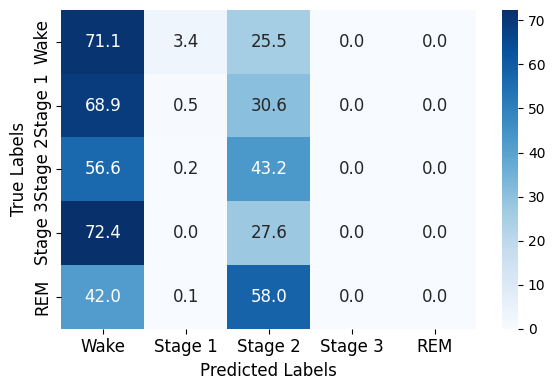

In [86]:
# Step 1: Get predicted labels (argmax on probabilities)
predicted_labels = np.argmax(all_outputs_filtered, axis=1)

fontsize = 12

# Step 2: Compute F1 score for each class
f1_scores = f1_score(all_targets_filtered, predicted_labels, average=None, labels=range(len(class_labels)))
for idx, label in enumerate(class_labels):
    print(f"F1 Score for {label}: {f1_scores[idx]:.3f}")

# Step 3: Create a confusion matrix and normalize it by row to get percentages
conf_matrix = confusion_matrix(all_targets_filtered, predicted_labels, labels=range(len(class_labels)))
conf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1, keepdims=True) * 100

# Plotting the confusion matrix with percentages
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={"size": fontsize},  # Font size for numbers inside the heatmap
    cbar_kws={"shrink": 1},  # Adjust colorbar size
)

# Customizing axis labels and ticks
plt.xlabel("Predicted Labels", fontsize=fontsize)
plt.ylabel("True Labels", fontsize=fontsize)
plt.xticks(fontsize=12, ha="center")  # Font size for x-axis tick labels with rotation
plt.yticks(fontsize=12)  # Font size for y-axis tick labels

# Adjust layout and save the figure
plt.tight_layout()
plt.show()

In [88]:
print("="*60)
print("🧪 TEST FINAL : PRÉDICTIONS")
print("="*60)

sleep_staging_model.eval()

for batch_idx, batch in enumerate(test_loader):
    x_batch, y_batch, mask_batch, paths = batch
    
    x_batch = x_batch.to(device)
    mask_batch = mask_batch.to(device)
    y_batch = y_batch.to(device)
    
    print(f"\n📦 Batch info:")
    print(f"   Input shape:  {x_batch.shape}")
    print(f"   Labels shape: {y_batch.shape}")
    print(f"   Mask shape:   {mask_batch.shape}")
    
    with torch.no_grad():
        output = sleep_staging_model(x_batch, mask_batch)
        
        if isinstance(output, tuple):
            logits = output[0]
        else:
            logits = output
    
    print(f"   Logits shape: {logits.shape}")
    
    # 1. PROBABILITÉS MOYENNES
    probs = torch.softmax(logits, dim=-1)
    probs_mean = probs.mean(dim=[0, 1])
    
    print(f"\n📊 PROBABILITÉS MOYENNES PAR CLASSE:")
    stage_names = ['Wake', 'REM', 'N1', 'N2', 'N3']
    
    for i, name in enumerate(stage_names):
        prob = probs_mean[i].item()
        bar = "█" * int(prob * 50)
        print(f"   {name:4s}: {prob:.4f} ({prob*100:5.1f}%) {bar}")
    
    # 2. DISTRIBUTION DES PRÉDICTIONS
    preds = torch.argmax(logits, dim=-1)
    
    print(f"\n🎯 DISTRIBUTION DES PRÉDICTIONS:")
    unique_preds, counts_preds = torch.unique(preds, return_counts=True)
    
    for stage_id, count in zip(unique_preds, counts_preds):
        stage_id = int(stage_id.item())  # ✅ CORRECTION
        count = count.item()
        pct = count / preds.numel() * 100
        bar = "█" * int(pct / 2)
        print(f"   {stage_names[stage_id]:4s}: {count:6d} ({pct:5.1f}%) {bar}")
    
    # Vérifier si toutes les classes sont prédites
    missing_classes = set(range(5)) - set([int(x.item()) for x in unique_preds])
    if missing_classes:
        missing_names = [stage_names[i] for i in missing_classes]
        print(f"\n   ⚠️  Jamais prédites: {missing_names}")
    else:
        print(f"\n   ✅ Toutes les classes sont prédites")
    
    # 3. DISTRIBUTION DES LABELS (vérité terrain)
    print(f"\n📋 DISTRIBUTION DES LABELS (vérité terrain):")
    valid_labels = y_batch[y_batch >= 0]
    
    if len(valid_labels) > 0:
        unique_labels, counts_labels = torch.unique(valid_labels, return_counts=True)
        
        for stage_id, count in zip(unique_labels, counts_labels):
            stage_id = int(stage_id.item())  # ✅ CORRECTION
            count = count.item()
            pct = count / len(valid_labels) * 100
            bar = "█" * int(pct / 2)
            print(f"   {stage_names[stage_id]:4s}: {count:6d} ({pct:5.1f}%) {bar}")
    else:
        print(f"   ❌ Aucun label valide !")
    
    # 4. ACCURACY
    print(f"\n🎯 ACCURACY:")
    valid_mask = y_batch >= 0
    
    if valid_mask.sum() > 0:
        correct = ((preds == y_batch) & valid_mask).sum().item()
        total = valid_mask.sum().item()
        accuracy = correct / total
        
        print(f"   Total samples:  {total}")
        print(f"   Correct:        {correct}")
        print(f"   Accuracy:       {accuracy*100:.2f}%")
        
        if accuracy > 0.60:
            print(f"   ✅ EXCELLENT (>60%)")
        elif accuracy > 0.40:
            print(f"   ✅ BON (>40%)")
        elif accuracy > 0.25:
            print(f"   ⚠️  AU-DESSUS DU HASARD (>25%)")
        else:
            print(f"   ❌ PROCHE DU HASARD (<25%) - Problème d'alignement probable")
    else:
        print(f"   ❌ Pas de labels valides pour calculer l'accuracy")
    
    # 5. MATRICE DE CONFUSION (aperçu)
    if valid_mask.sum() > 0:
        from sklearn.metrics import confusion_matrix
        import numpy as np
        
        preds_valid = preds[valid_mask].cpu().numpy()
        labels_valid = y_batch[valid_mask].cpu().numpy()
        
        cm = confusion_matrix(labels_valid, preds_valid, labels=[0, 1, 2, 3, 4])
        
        print(f"\n📊 MATRICE DE CONFUSION:")
        print(f"           Prédit →")
        print(f"   Vrai ↓  Wake  REM   N1    N2    N3")
        
        for i, name in enumerate(stage_names):
            row = cm[i]
            row_str = "  ".join([f"{val:5d}" for val in row])
            print(f"   {name:4s}   {row_str}")
        
        # Calculer l'accuracy par classe
        print(f"\n📈 RECALL PAR CLASSE:")
        for i, name in enumerate(stage_names):
            if cm[i].sum() > 0:
                recall = cm[i, i] / cm[i].sum()
                bar = "█" * int(recall * 30)
                print(f"   {name:4s}: {recall*100:5.1f}% {bar}")
    
    break  # Premier batch seulement

print(f"\n{'='*60}")

🧪 TEST FINAL : PRÉDICTIONS

📦 Batch info:
   Input shape:  torch.Size([1, 4, 6540, 128])
   Labels shape: torch.Size([1, 6540])
   Mask shape:   torch.Size([1, 4, 6540])
   Logits shape: torch.Size([1, 6540, 5])

📊 PROBABILITÉS MOYENNES PAR CLASSE:
   Wake: 0.6737 ( 67.4%) █████████████████████████████████
   REM : 0.1126 ( 11.3%) █████
   N1  : 0.1970 ( 19.7%) █████████
   N2  : 0.0033 (  0.3%) 
   N3  : 0.0134 (  1.3%) 

🎯 DISTRIBUTION DES PRÉDICTIONS:
   Wake:   5726 ( 87.6%) ███████████████████████████████████████████
   REM :     34 (  0.5%) 
   N1  :    780 ( 11.9%) █████

   ⚠️  Jamais prédites: ['N2', 'N3']

📋 DISTRIBUTION DES LABELS (vérité terrain):
   Wake:    906 ( 13.9%) ██████
   REM :    222 (  3.4%) █
   N1  :   3246 ( 49.6%) ████████████████████████
   N2  :    774 ( 11.8%) █████
   N3  :   1392 ( 21.3%) ██████████

🎯 ACCURACY:
   Total samples:  6540
   Correct:        1223
   Accuracy:       18.70%
   ❌ PROCHE DU HASARD (<25%) - Problème d'alignement probable

📊 MATR